# 🎓 Modelo Preditivo de Defasagem Escolar

Este notebook apresenta a construção, treinamento e validação de um modelo baseado em **Random Forest Classifier** para prever se um aluno está em trajetória de defasagem escolar crescente (fase real atrasada em relação à fase ideal para a idade).

**Objetivo:** Identificar precocemente alunos em risco, alcançando uma eficácia mínima superior a 75%.

In [57]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix, 
    ConfusionMatrixDisplay, roc_curve, auc
)

# Configuração de estilo visual para os gráficos
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 📁 1. Carregamento da Base de Dados

In [58]:
# Carregamento dos dados especificando o separador e codificação requisitada
df = pd.read_csv('BASE DE DADOS PEDE 2024 - DATATHON - NORMALIZADA.txt', sep=';', encoding='utf-8')

print(f"Total de registros carregados: {df.shape[0]}")
print(f"Total de colunas originais: {df.shape[1]}")

Total de registros carregados: 3030
Total de colunas originais: 53


In [59]:
df.head(5)

,RA,Fase,Turma,Nome,Data de Nasc,Ano Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Origem
0,RA-1,7,A,ALUNO-1,NaN,2003,19.0,MENINA,2016,ESCOLA PÚBLICA,...,7.278,5.0,FASE 8 (UNIVERSITÁRIOS),-1,MELHORAR: MELHORAR A SUA ENTREGA DE LIÇÕES DE ...,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,MELHORAR: INTEGRAR-SE MAIS AOS PRINCÍPIOS PASS...,NaN,NaN,PEDE2022
1,RA-2,7,A,ALUNO-2,NaN,2005,17.0,MENINA,2017,REDE DECISÃO,...,6.778,10.0,FASE 7 (3º EM),0,MELHORAR: MELHORAR A SUA ENTREGA DE LIÇÕES DE ...,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,MELHORAR: INTEGRAR-SE MAIS AOS PRINCÍPIOS PASS...,NaN,NaN,PEDE2022
2,RA-3,7,A,ALUNO-3,NaN,2005,17.0,MENINA,2016,REDE DECISÃO,...,7.556,10.0,FASE 7 (3º EM),0,DESTAQUE: A SUA BOA ENTREGA DAS LIÇÕES DE CASA.,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,DESTAQUE: A SUA BOA INTEGRAÇÃO AOS PRINCÍPIOS ...,NaN,NaN,PEDE2022
3,RA-4,7,A,ALUNO-4,NaN,2005,17.0,MENINO,2017,REDE DECISÃO,...,5.278,10.0,FASE 7 (3º EM),0,MELHORAR: MELHORAR A SUA ENTREGA DE LIÇÕES DE ...,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,MELHORAR: INTEGRAR-SE MAIS AOS PRINCÍPIOS PASS...,NaN,NaN,PEDE2022
4,RA-5,7,A,ALUNO-5,NaN,2005,17.0,MENINA,2016,REDE DECISÃO,...,7.389,10.0,FASE 7 (3º EM),0,DESTAQUE: A SUA BOA ENTREGA DAS LIÇÕES DE CASA.,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,MELHORAR: INTEGRAR-SE MAIS AOS PRINCÍPIOS PASS...,NaN,NaN,PEDE2022


In [60]:
df.tail(5)

,RA,Fase,Turma,Nome,Data de Nasc,Ano Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Origem
3025,RA-1658,9,9,ALUNO-1658,2002-12-14,2002,21.0,MASCULINO,2021,PRIVADA,...,NaN,10.0,FASE 8 (UNIVERSITÁRIOS),1,NaN,NaN,NaN,FACULDADE (FIAP),CURSANDO,PEDE2024
3026,RA-1659,9,9,ALUNO-1659,2003-02-04,2003,21.0,MASCULINO,2021,BOLSISTA UNIVERSITÁRIO *FORMADO (A),...,NaN,10.0,FASE 8 (UNIVERSITÁRIOS),1,NaN,NaN,NaN,BOLSISTA UNIVERSITÁRIO *FORMADO (A),CURSANDO,PEDE2024
3027,RA-1252,9,9,ALUNO-1252,2002-06-03,2002,22.0,FEMININO,2021,PRIVADA,...,NaN,10.0,FASE 8 (UNIVERSITÁRIOS),1,NaN,NaN,NaN,FACULDADE (FIAP),CURSANDO,PEDE2024
3028,RA-1660,9,9,ALUNO-1660,2000-06-28,2000,24.0,FEMININO,2021,BOLSISTA UNIVERSITÁRIO *FORMADO (A),...,NaN,10.0,FASE 8 (UNIVERSITÁRIOS),1,NaN,NaN,NaN,BOLSISTA UNIVERSITÁRIO *FORMADO (A),CURSANDO,PEDE2024
3029,RA-1661,9,9,ALUNO-1661,2003-01-29,2003,21.0,FEMININO,2021,BOLSISTA UNIVERSITÁRIO *FORMADO (A),...,NaN,10.0,FASE 8 (UNIVERSITÁRIOS),1,NaN,NaN,NaN,BOLSISTA UNIVERSITÁRIO *FORMADO (A),CURSANDO,PEDE2024


## 🛠️ 2. Feature Engineering e Tratamento

Criamos as features consolidadas unificando as colunas anuais, limpamos campos de texto e extraímos o ano de referência.

In [61]:
# 2.1. Função para converter a coluna 'Fase' em numérica limpa
def extrair_fase_numerica(fase_str):
    f = str(fase_str).upper().strip()
    # Considerar turmas 'Alfa' como fase de alfabetização/início (fase 0)
    if 'ALFA' in f:
        return 0.0
    # Captura o primeiro número encontrado na string (ex: 'FASE 1' -> 1, '1A' -> 1)
    match = re.search(r'\d+', f)
    return float(match.group()) if match else np.nan

df['Fase_Cleansed'] = df['Fase'].apply(extrair_fase_numerica)

# 2.2. Unificação de métricas anuais
# Como o dataset espalha métricas por anos (Pedra 24, Pedra 23, etc), faremos a consolidação priorizando a métrica mais recente disponível para cada linha.
df['INDE_Consolidado'] = df['INDE 24'].fillna(df['INDE 23']).fillna(df['INDE 22'])
df['Pedra_Consolidada'] = df['Pedra 24'].fillna(df['Pedra 23']).fillna(df['Pedra 22']).fillna(df['Pedra 21']).fillna(df['Pedra 20'])

# 2.3. Extração do Ano de Referência do registro
# Obtido a partir da coluna Origem que indica a fonte ('PEDE2022', 'PEDE2023', etc)
df['Ano_Referencia'] = df['Origem'].str.extract(r'(\d+)').astype(float)

print("Feature Engineering concluído com sucesso.")

Feature Engineering concluído com sucesso.


## 🎯 3. Definição da Variável Alvo (Target)

O objetivo é prever se a fase real do aluno está atrasada em relação à fase ideal. 
No conjunto de dados original:
- Uma defasagem negativa (`Defasagem < 0`) simboliza atraso real.

Criamos uma variável intermediária `Defas` que converte o atraso em valor positivo, de modo que a nossa meta `Target = (Defas > 0)` reflita com precisão o estado de risco de defasagem escolar.

Distribuição do Target:
Classe 0 (Sem Atraso): 44.32%
Classe 1 (Com Defasagem): 55.68%


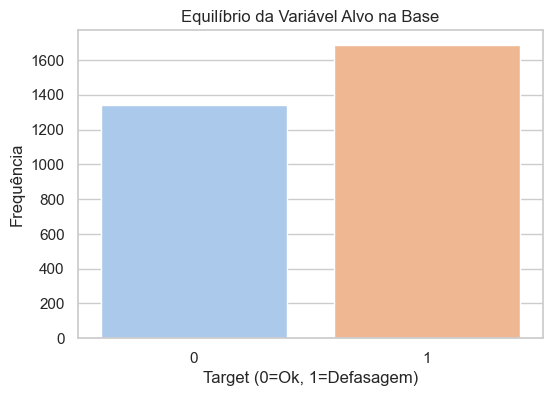

In [62]:
# Definindo 'Defas' como o módulo da defasagem negativa, mapeando a lógica pedida
df['Defas'] = df['Defasagem'].apply(lambda x: abs(x) if x < 0 else 0)

# Criando a classe binária final para o modelo prever (1 = Em Risco de Defasagem, 0 = Saudável/Sem Atraso)
df['Target'] = (df['Defas'] > 0).astype(int)

distribuicao = df['Target'].value_counts(normalize=True) * 100
print("Distribuição do Target:")
print(f"Classe 0 (Sem Atraso): {distribuicao[0]:.2f}%")
print(f"Classe 1 (Com Defasagem): {distribuicao[1]:.2f}%")

# Gráfico de balanceamento do Target
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df, hue='Target', legend=False)
plt.title('Equilíbrio da Variável Alvo na Base')
plt.xlabel('Target (0=Ok, 1=Defasagem)')
plt.ylabel('Frequência')
plt.show()

### ⚠️ Nota Importante sobre Data Leakage e IAN (Adequação ao Nível)

Durante a análise exploratória, identificou-se que o `IAN` possui uma relação matemática direta e determinística com a variável Alvo (todos os alunos sem defasagem possuem IAN cravado em 10.0, enquanto os que possuem qualquer defasagem possuem IAN <= 5.0).

**Optamos por remover o IAN** das features de treinamento para evitar o vazamento de dados, permitindo que o algoritmo aprenda os padrões comportamentais e educacionais reais do aluno, e não apenas um atalho aritmético que inflaria a precisão artificialmente para 100%.

## 🏗️ 4. Preparação do Conjunto de Dados e Pipeline

Separamos as variáveis e configuramos o pré-processamento para lidar com valores nulos e codificação de categorias.

In [63]:
# Definição das variáveis preditoras conforme o escopo do modelo
num_features = ['Fase_Cleansed', 'INDE_Consolidado', 'IAA', 'IEG', 'IPS', 'IDA', 'Ano ingresso', 'Ano_Referencia']
cat_features = ['Gênero', 'Pedra_Consolidada', 'Instituição de ensino']

X = df[num_features + cat_features].copy()
y = df['Target']

# 4.1. Pipeline de Tratamento Numérico (Preenchimento com a mediana e Padronização)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4.2. Pipeline de Tratamento Categórico (Preenchimento com valor mais frequente e OneHot Encoding)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 4.3. Combinador de Pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print("Pipeline de pré-processamento construído com sucesso.")

Pipeline de pré-processamento construído com sucesso.


## 🚀 5. Treinamento do Modelo

Dividimos os dados em Treino (70%) e Teste (30%), estratificando o target para garantir representatividade de ambas as classes em ambos os splits.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

# Definição do Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=7, 
    min_samples_leaf=10,
    class_weight='balanced', 
    random_state=42
)

# Acoplamento do modelo final ao pipeline
full_model = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', rf_clf)
])

# Treino
full_model.fit(X_train, y_train)

print("Modelo Random Forest treinado!")

Modelo Random Forest treinado!


## 📊 6. Avaliações e Validações do Modelo

Métricas: Matrix de confusão, Relatório de Classificação e Acurácia, comprovando a eficácia.

### 6.1 Acurácia do modelo

In [65]:
y_pred = full_model.predict(X_test)
y_proba = full_model.predict_proba(X_test)[:, 1]

final_acc = accuracy_score(y_test, y_pred)

print(f"===========================================================")
print(f"🏆 RESULTADO FINAL DA ACURÁCIA: {final_acc * 100:.2f}%")
print(f"Mínimo de 75% alcançada? {'SIM ✅' if final_acc >= 0.75 else 'NÃO ❌'}")
print(f"===========================================================\n")

print("📄 RELATÓRIO TÉCNICO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred, target_names=['Classe 0 (Sem Defasagem)', 'Classe 1 (Em Defasagem)']))

🏆 RESULTADO FINAL DA ACURÁCIA: 78.55%
Mínimo de 75% alcançada? SIM ✅

📄 RELATÓRIO TÉCNICO DE CLASSIFICAÇÃO:
                          precision    recall  f1-score   support

Classe 0 (Sem Defasagem)       0.78      0.71      0.75       403
 Classe 1 (Em Defasagem)       0.79      0.84      0.81       506

                accuracy                           0.79       909
               macro avg       0.79      0.78      0.78       909
            weighted avg       0.79      0.79      0.78       909



### 6.2 Matrix de Confusão
Revela o quão bem o modelo separa os Verdadeiros Positivos e os Falsos Positivos.

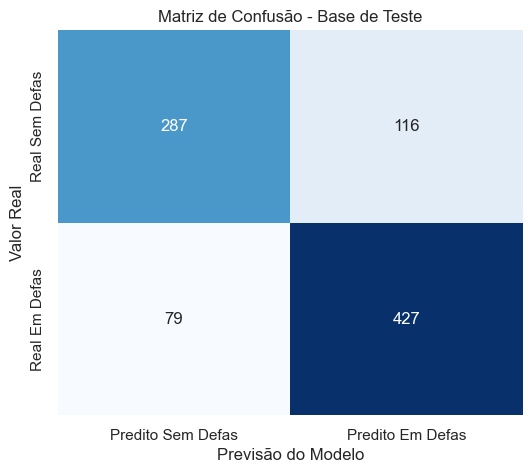

In [66]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predito Sem Defas', 'Predito Em Defas'],
            yticklabels=['Real Sem Defas', 'Real Em Defas'])
plt.title('Matriz de Confusão - Base de Teste')
plt.ylabel('Valor Real')
plt.xlabel('Previsão do Modelo')
plt.show()

### 6.3 Curva ROC e Área Sob a Curva (AUC)
Medimos capacidade de discriminação do modelo através de diferentes thresholds de probabilidade.

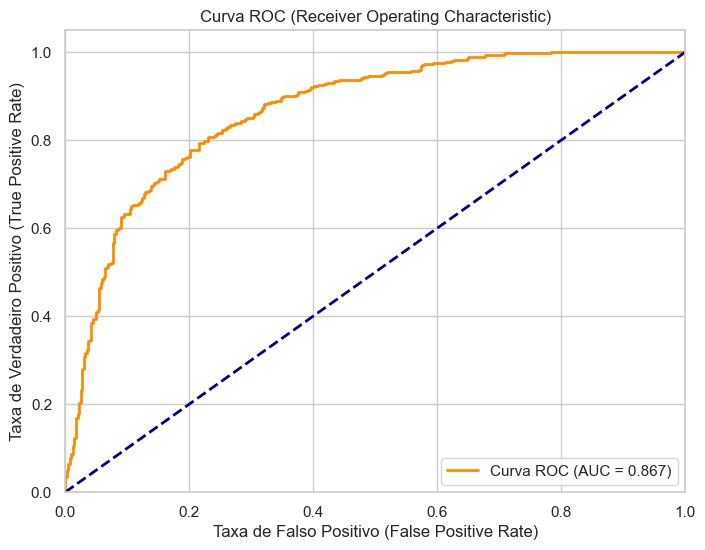

In [67]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiro Positivo (True Positive Rate)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

### 6.4 Importância das Variáveis
Quais features o Random Forest considerou mais cruciais para tomar a decisão de risco?

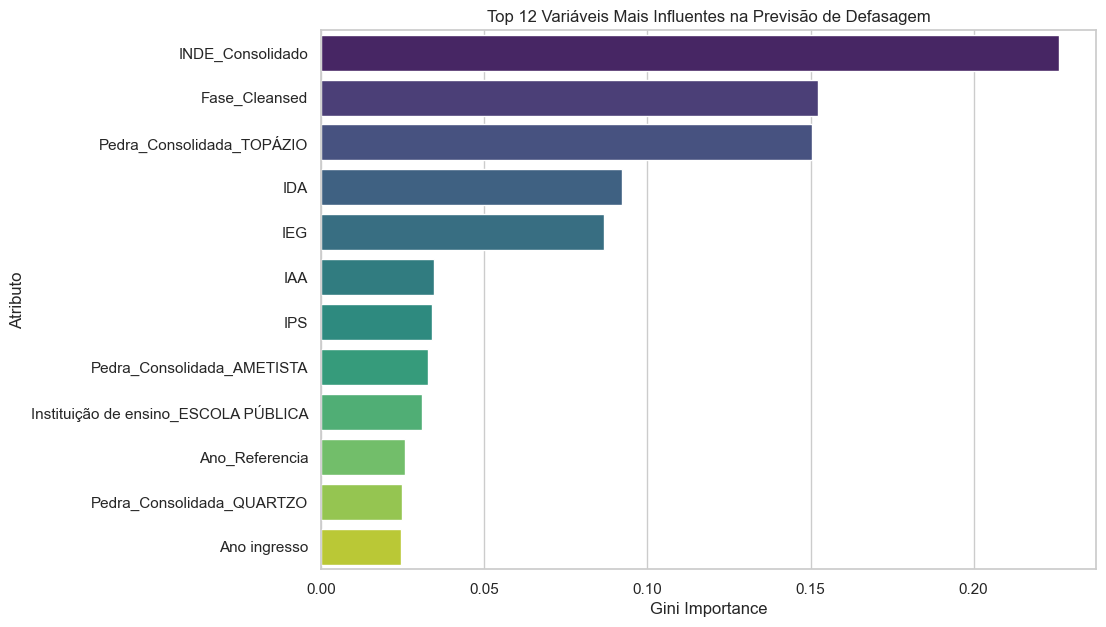

In [68]:
# Recuperando nomes das colunas após OneHotEncoding
ohe_names = full_model.named_steps['pre'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features)
feature_names = list(num_features) + list(ohe_names)

# Obtendo a importância
importances = full_model.named_steps['model'].feature_importances_

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(12), palette='viridis')
plt.title('Top 12 Variáveis Mais Influentes na Previsão de Defasagem')
plt.xlabel('Gini Importance')
plt.ylabel('Atributo')
plt.show()

### 6.5 Validação Cruzada (Cross-Validation)
Garantir que os resultados não são frutos do acaso por sorteio e que o modelo é estável.

In [69]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(full_model, X, y, cv=kfold, scoring='accuracy')

print("--- RESULTADOS DA VALIDAÇÃO CRUZADA ESTRATIFICADA (K-FOLD) ---")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold}: Acurácia = {score * 100:.2f}%")

print(f"\nDesempenho Médio Geral: {cv_scores.mean() * 100:.2f}%")
print(f"Desvio Padrão (Estabilidade): {cv_scores.std():.4f}")

--- RESULTADOS DA VALIDAÇÃO CRUZADA ESTRATIFICADA (K-FOLD) ---
Fold 1: Acurácia = 78.05%
Fold 2: Acurácia = 80.69%
Fold 3: Acurácia = 77.39%
Fold 4: Acurácia = 76.24%
Fold 5: Acurácia = 77.72%

Desempenho Médio Geral: 78.02%
Desvio Padrão (Estabilidade): 0.0147


## 💾 7. Exportação do Modelo para um arquivo *.joblib

Nesta etapa final, salvamos o modelo completo (incluindo todo o Pipeline de pré-processamento) em um arquivo `.joblib`. Isso permite que ele seja carregado instantaneamente em um simulador Web (ex: Streamlit).

In [70]:
import joblib
import os

nome_arquivo = 'modelo_evandro_random_forest_joblib.joblib'

if os.path.exists(nome_arquivo):
    os.remove(nome_arquivo)
    print(f"\nArquivo '{nome_arquivo}' existente removido.")

joblib.dump(full_model, nome_arquivo)
print(f"✅ Pipeline do modelo salvo com sucesso em '{nome_arquivo}'!")

✅ Pipeline do modelo salvo com sucesso em 'modelo_evandro_random_forest_joblib.joblib'!
